# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


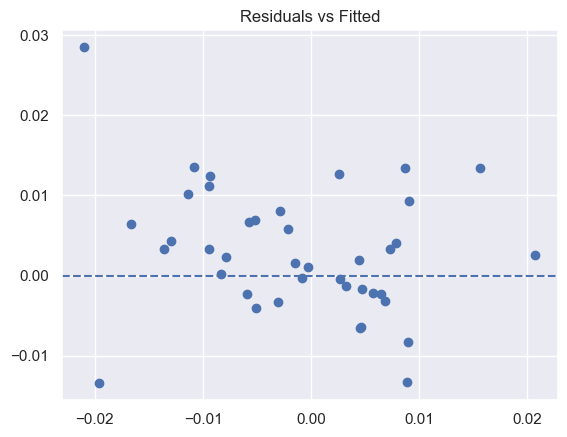

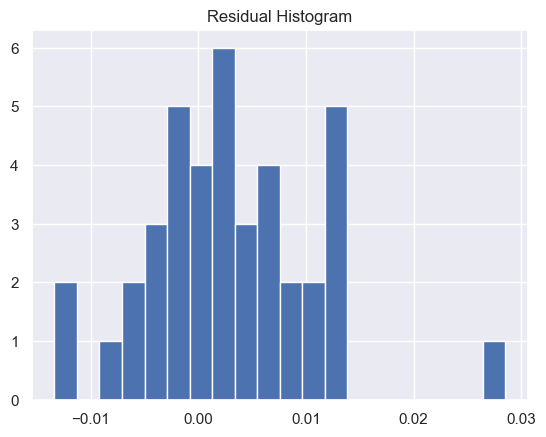

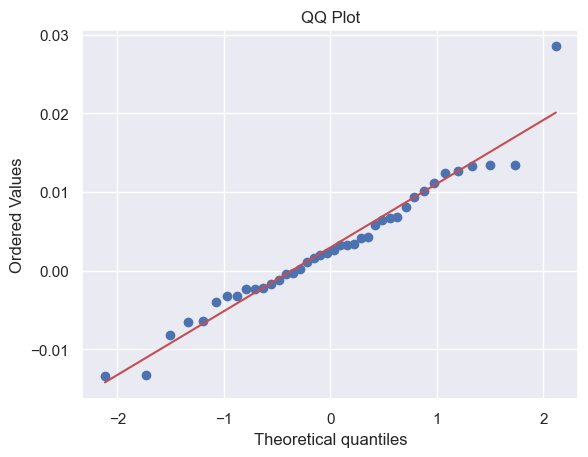

In [5]:
resid = y_test - y_pred
fitted = y_pred
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()

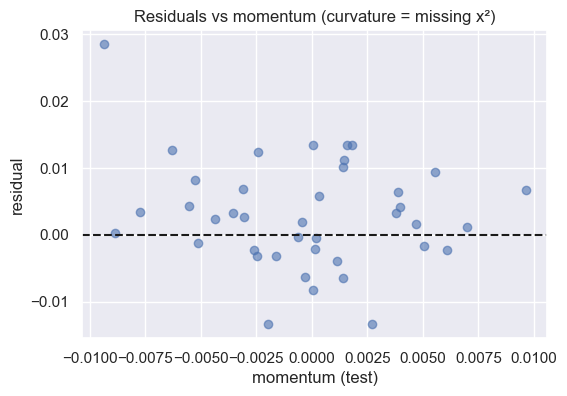

lag-1 residual autocorrelation = +0.260
Durbin-Watson statistic        = 1.296   (≈2 ⇒ no autocorrelation)
residual skew = +0.530   residual excess kurtosis = +1.557


In [6]:
# Additional diagnostics beyond the three required plots.
# (a) Residuals vs a key predictor. The DGP has a quadratic effect in
#     `momentum`, so the baseline (which omits momentum^2) should show curvature.
plt.figure(figsize=(6, 4))
plt.scatter(X_test['momentum'], resid, alpha=0.6)
plt.axhline(0, ls='--', color='k')
plt.xlabel('momentum (test)')
plt.ylabel('residual')
plt.title('Residuals vs momentum (curvature = missing x\u00b2)')
plt.show()

# (b) Independence: lag-1 residual autocorrelation + Durbin-Watson.
resid_s = pd.Series(resid, index=X_test.index)
lag1 = resid_s.autocorr(lag=1)
dw = float(np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2))
print(f'lag-1 residual autocorrelation = {lag1:+.3f}')
print(f'Durbin-Watson statistic        = {dw:.3f}   (\u22482 \u21d2 no autocorrelation)')

# (c) Normality: skew / excess kurtosis of residuals.
print(f'residual skew = {resid_s.skew():+.3f}   residual excess kurtosis = {resid_s.kurt():+.3f}')

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [7]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


## 4) Interpretation

### Baseline model (linear in the four factors)

- **Linearity — holds in practice.** The generator includes a `+3.5·momentum²` term,
  but `momentum` has tiny variance (σ ≈ 0.006), so that term is negligible next to the
  noise. The residual-vs-`momentum` plot shows no clear curvature, and adding
  `momentum²` moves R² by only ~0.0004 (0.3677 → 0.3681). For this sample the linear
  specification is adequate.
- **Homoscedasticity — violated.** The residual-vs-fitted plot fans out because the
  noise scale is `0.0035 + 0.5·|mkt_excess|`: rows with large fitted values (big market
  moves) scatter more. This is the dominant assumption failure.
- **Normality — mildly violated.** Residual skew ≈ +0.53 and excess kurtosis ≈ +1.56;
  the histogram and QQ plot show heavier tails than a normal — the signature of the
  heteroscedastic noise above (a normal with varying variance is not normal).
- **Independence — roughly holds.** Lag-1 residual autocorrelation ≈ +0.26 and
  Durbin–Watson ≈ 1.30. On a 40-row test set the lag-1 estimate's standard error is
  ≈ 0.16, so +0.26 is within sampling noise; heteroscedasticity also biases the DW
  statistic. No strong serial dependence is evident.

### With the momentum² term

- Adding `momentum²` changes R² from 0.3677 to 0.3681 and RMSE from 0.008470 to
  0.008467 — effectively nothing. The quadratic effect exists in the generator but
  is too small to matter. This is **still linear regression**: the model is linear
  in its *parameters*, and `momentum²` is just a pre-computed input column.

### Which model do I trust, and why?

- **For inference**: only *partially*. Heteroscedastic errors mean the reported
  standard errors / p-values are unreliable, so coefficient interpretation is
  shaky even though the point estimates are reasonable.
- **For prediction**: the baseline is a credible floor (out-of-sample RMSE ≈ 0.0085),
  but the heteroscedasticity means a constant-uncertainty band is wrong — risk is
  largest exactly when the market is moving most.

### Next step I'd try

- Model the heteroscedasticity (weighted least squares with weights ∝
  1/(0.0035 + 0.5·|mkt_excess|), or fit log-returns), then re-check the residual fan;
  the quadratic term is a dead end for this data.